# 📋 Ejercicio en Clase — Métricas de Evaluación para Clasificación
## Diplomado ML en Seguros · Subtema 3

---

### Contexto del ejercicio

Eres actuario en **RenuevAuto**, aseguradora de autos con 180,000 pólizas vigentes. Cada año, entre el 18% y el 22% de los clientes **no renuevan** su póliza al vencimiento (cancelan o migran a la competencia).

El área de Retención necesita un modelo para identificar, **30 días antes del vencimiento**, qué clientes tienen alta probabilidad de NO renovar. Con esa lista, los ejecutivos de retención pueden llamarles y ofrecer un descuento o mejora de cobertura.

**El problema de negocio:** cada llamada de retención cuesta $280 pesos (tiempo del ejecutivo). Si se llama a todos los clientes (180,000), el costo total es $50.4 millones. El objetivo del modelo es enfocar las llamadas en los clientes que **realmente** no van a renovar, para no desperdiciar recursos en clientes que iban a renovar de todas formas.

### Variables del expediente

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `anios_cliente` | Numérica | Años como cliente de RenuevAuto (0–20) |
| `num_polizas` | Entera | Número de pólizas activas del cliente (1–4) |
| `edad_conductor` | Numérica | Edad del conductor principal (18–70) |
| `prima_actual_k` | Numérica | Prima actual en MXN miles |
| `incremento_prima_pct` | Numérica | % de incremento en la última renovación (0–40%) |
| `siniestros_ultimo_anio` | Entera | Siniestros reportados en el último año (0–3) |
| `dias_sin_siniestro` | Entera | Días desde el último siniestro (0–730) |
| `uso_app` | Binaria | 1 = usa la app móvil, 0 = no la usa |
| `canal_venta` | Entera | 0=Agente, 1=Digital, 2=Broker |
| `quejas_12m` | Entera | Quejas formales en los últimos 12 meses (0–3) |
| `competidor_cotizo` | Binaria | 1 = solicitó cotización en la competencia, 0 = no |
| **`no_renueva`** | **Binaria** | **Variable objetivo**: 1 = no renueva, 0 = sí renueva |

---

### Qué vas a practicar

| Sección | Métricas |
|---------|----------|
| 3 | Matriz de confusión: VP, FN, FP, VN y análisis económico |
| 4 | Accuracy — por qué es engañosa con clases desbalanceadas |
| 5 | Precisión, Recall, Especificidad con cálculo manual |
| 6 | F1-Score y familia Fβ (F0.5 y F2) |
| 7 | Efecto del umbral de decisión |
| 8 | Curva ROC, AUC e Índice de Gini |
| 9 | Selección del umbral óptimo (Youden y costos) |
| 10 | Comparación de 3 modelos y decisión final |

---

**Instrucciones:** Las celdas con 🔧 requieren que escribas código. Las celdas con 📝 requieren responder preguntas. No cambies `random_state=2024`.

**Tiempo estimado:** 90 minutos

---
## Parte 0 — Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Preprocesamiento y validación
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Métricas de clasificación — todas las del Subtema 3
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

np.random.seed(2024)
plt.rcParams.update({'figure.figsize': (12, 4), 'font.size': 11})
print("✅ Librerías listas.")

✅ Librerías listas.


---
## Parte 1 — Generar el portafolio de RenuevAuto

Ejecuta esta celda sin modificarla. Genera **2,500 pólizas** próximas a vencer.

In [2]:
# ─── Portafolio RenuevAuto — NO MODIFICAR ───────────────────────────────────
np.random.seed(2024)
N = 2500

# Características del cliente y la póliza
anios_cliente        = np.random.choice(range(0, 21), N,
                           p=[0.10,0.12,0.11,0.09,0.08,0.07,0.06,0.05,0.05,
                              0.04,0.04,0.03,0.03,0.03,0.02,0.02,0.02,0.01,0.01,0.01,0.01])
num_polizas          = np.random.choice([1, 2, 3, 4], N, p=[0.60, 0.26, 0.10, 0.04])
edad_conductor       = np.random.randint(18, 71, N)
prima_actual_k       = np.clip(np.random.lognormal(np.log(12), 0.5, N), 4, 45).round(2)
incremento_prima_pct = np.clip(np.random.exponential(8, N), 0, 40).round(1)
siniestros_ultimo    = np.random.choice([0, 1, 2, 3], N, p=[0.64, 0.26, 0.08, 0.02])
dias_sin_siniestro   = np.where(siniestros_ultimo == 0,
                           np.random.randint(200, 731, N),
                           np.random.randint(0, 365, N))
uso_app              = np.random.binomial(1, 0.42, N)
canal_venta          = np.random.choice([0, 1, 2], N, p=[0.48, 0.32, 0.20])
quejas_12m           = np.random.choice([0, 1, 2, 3], N, p=[0.78, 0.16, 0.05, 0.01])
competidor_cotizo    = np.random.binomial(1, 0.24, N)

# Probabilidad de NO renovar: función logística de las variables
# Factores que AUMENTAN la probabilidad de no renovar:
#   - incremento alto de prima, quejas, cotizó con la competencia
#   - sin historial en la empresa (nuevo), muchos siniestros recientes
# Factores que REDUCEN la probabilidad de no renovar:
#   - cliente antiguo, múltiples pólizas, usa la app
log_odds = (
    -1.20
    - 0.18 * anios_cliente          # más años → más leal
    - 0.55 * num_polizas            # más pólizas → más caro cambiar
    + 0.05 * incremento_prima_pct   # mayor incremento → más molestia
    + 0.40 * siniestros_ultimo      # siniestros → posible insatisfacción
    - 0.35 * uso_app                # usa app → más comprometido
    + 0.80 * quejas_12m             # quejas → señal de alerta fuerte
    + 1.40 * competidor_cotizo      # cotizó competencia → alta intención de irse
    + 0.30 * (canal_venta == 1)     # canal digital → menos lealtad
    + np.random.normal(0, 0.6, N)   # ruido individual
)
prob_no_renueva = 1 / (1 + np.exp(-log_odds))
no_renueva = (np.random.rand(N) < prob_no_renueva).astype(int)

# Armar DataFrame
df = pd.DataFrame({
    'anios_cliente':         anios_cliente,
    'num_polizas':           num_polizas,
    'edad_conductor':        edad_conductor,
    'prima_actual_k':        prima_actual_k,
    'incremento_prima_pct':  incremento_prima_pct,
    'siniestros_ultimo_anio':siniestros_ultimo,
    'dias_sin_siniestro':    dias_sin_siniestro,
    'uso_app':               uso_app,
    'canal_venta':           canal_venta,
    'quejas_12m':            quejas_12m,
    'competidor_cotizo':     competidor_cotizo,
    'no_renueva':            no_renueva
})

tasa_churn = no_renueva.mean()
print(f"✅ Portafolio RenuevAuto: {N:,} pólizas próximas a vencer")
print(f"\n   Clientes que NO renuevan (churn): {no_renueva.sum():,} ({tasa_churn*100:.1f}%)")
print(f"   Clientes que SÍ renuevan:         {(1-no_renueva).sum():,} ({(1-tasa_churn)*100:.1f}%)")
print(f"\n   Prima promedio:       ${df.prima_actual_k.mean():.1f}K")
print(f"   Incremento promedio:  {df.incremento_prima_pct.mean():.1f}%")
print(f"   Años promedio como cliente: {df.anios_cliente.mean():.1f} años")
print("\nPrimeras 5 filas:")
df.head()

✅ Portafolio RenuevAuto: 2,500 pólizas próximas a vencer

   Clientes que NO renuevan (churn): 462 (18.5%)
   Clientes que SÍ renuevan:         2,038 (81.5%)

   Prima promedio:       $13.6K
   Incremento promedio:  8.0%
   Años promedio como cliente: 6.0 años

Primeras 5 filas:


,anios_cliente,num_polizas,edad_conductor,prima_actual_k,incremento_prima_pct,siniestros_ultimo_anio,dias_sin_siniestro,uso_app,canal_venta,quejas_12m,competidor_cotizo,no_renueva
0,6,1,52,9.41,4.6,0,204,1,0,0,1,0
1,8,1,30,20.95,1.0,2,12,0,2,1,0,1
2,1,1,53,26.47,1.6,1,362,1,0,0,0,1
3,0,1,34,25.40,15.1,0,207,0,0,0,1,0
4,1,2,54,20.13,5.0,2,179,0,2,0,0,1


### 🔧 1.1 — Exploración rápida del churn

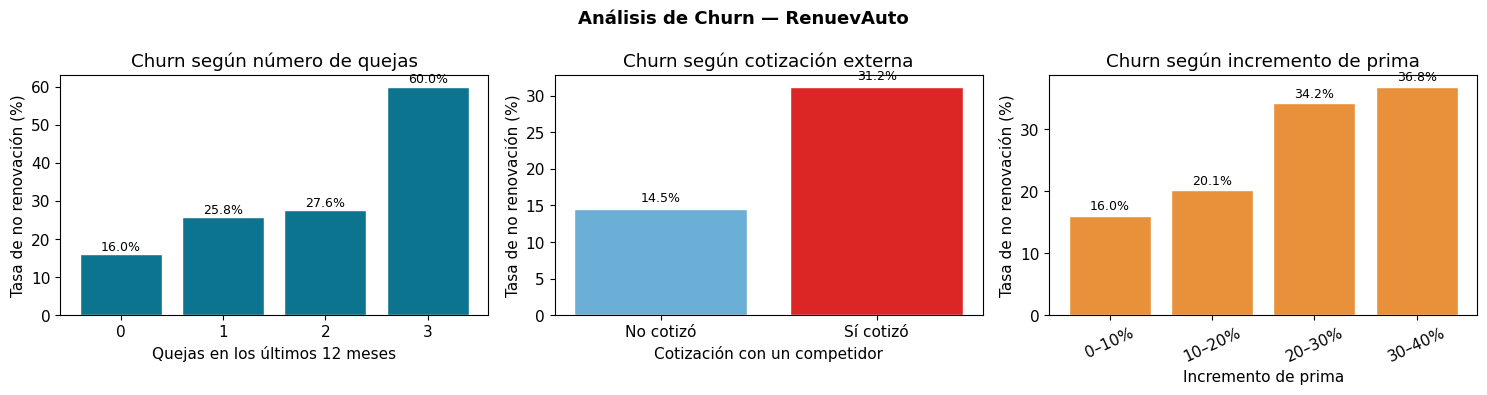

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Análisis de Churn — RenuevAuto', fontsize=13, fontweight='bold')

# Panel 1: tasa de churn por número de quejas
ax = axes[0]
# 🔧 COMPLETA: calcula la tasa de churn (no_renueva.mean()) por quejas_12m
# Pista: df.groupby('quejas_12m')['no_renueva'].mean()
# --- TU CÓDIGO AQUÍ ---
churn_quejas = (
    df.groupby("quejas_12m")["no_renueva"].mean()
    .mul(100)
)

ax.bar(
    churn_quejas.index.astype(str),
    churn_quejas.values,
    color="#0D7490",
    edgecolor="white"
)

ax.set_xlabel("Quejas en los últimos 12 meses")
ax.set_ylabel("Tasa de no renovación (%)")
ax.set_title("Churn según número de quejas")

for i, valor in enumerate(churn_quejas.values):
    ax.text(
        i,
        valor + 1,
        f"{valor:.1f}%",
        ha="center",
        fontsize=9
    )


# Panel 2: tasa de churn según si cotizó con la competencia
ax = axes[1]
# 🔧 COMPLETA: tasa de churn para competidor_cotizo=0 vs competidor_cotizo=1
# --- TU CÓDIGO AQUÍ ---
churn_competidor = (
    df.groupby("competidor_cotizo")["no_renueva"]
    .mean()
    .mul(100)
)

ax.bar(
    ["No cotizó", "Sí cotizó"],
    churn_competidor.values,
    color=["#6BAED6", "#DC2626"],
    edgecolor="white"
)

ax.set_xlabel("Cotización con un competidor")
ax.set_ylabel("Tasa de no renovación (%)")
ax.set_title("Churn según cotización externa")

for i, valor in enumerate(churn_competidor.values):
    ax.text(
        i,
        valor + 1,
        f"{valor:.1f}%",
        ha="center",
        fontsize=9
    )



# Panel 3: tasa de churn por incremento de prima (bins de 0-10%, 10-20%, 20-30%, >30%)
ax = axes[2]
# 🔧 COMPLETA: crea bins con pd.cut y grafica la tasa de churn por bin
# Pista: pd.cut(df['incremento_prima_pct'], bins=[0, 10, 20, 30, 40])
# --- TU CÓDIGO AQUÍ ---

df["rango_incremento"] = pd.cut(
    df["incremento_prima_pct"],
    bins=[0, 10, 20, 30, 40],
    labels=["0–10%", "10–20%", "20–30%", "30–40%"],
    include_lowest=True
)

churn_incremento = (
    df.groupby(
        "rango_incremento",
        observed=False
    )["no_renueva"]
    .mean()
    .mul(100)
)

ax.bar(
    churn_incremento.index.astype(str),
    churn_incremento.values,
    color="#E8913A",
    edgecolor="white"
)

ax.set_xlabel("Incremento de prima")
ax.set_ylabel("Tasa de no renovación (%)")
ax.set_title("Churn según incremento de prima")
ax.tick_params(axis="x", rotation=25)

for i, valor in enumerate(churn_incremento.values):
    ax.text(
        i,
        valor + 1,
        f"{valor:.1f}%",
        ha="center",
        fontsize=9
    )


plt.tight_layout()
plt.show()

### 📝 Preguntas 1.1

**a)** ¿Cuál de las tres variables exploradas parece tener mayor impacto en la decisión de no renovar? ¿Por qué crees que es así desde el punto de vista del cliente?

> _Escribe tu respuesta aquí_
El número de quejas parece tener el mayor impacto. Esto refleja insatisfacción acumulada
---

---
## Parte 2 — Preparar datos y entrenar el modelo base

### 🔧 2.1 — Separar train/test y entrenar un GBM

In [13]:
FEATURES = ['anios_cliente', 'num_polizas', 'edad_conductor',
            'prima_actual_k', 'incremento_prima_pct',
            'siniestros_ultimo_anio', 'dias_sin_siniestro',
            'uso_app', 'canal_venta', 'quejas_12m', 'competidor_cotizo']

X = df[FEATURES].values
y = df['no_renueva'].values

# 🔧 COMPLETA: separa train (80%) y test (20%)
# Usa stratify=y para mantener la proporción de churn
# --- TU CÓDIGO AQUÍ ---
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=2024,stratify=y)

print(f"Train: {len(X_train):,} pólizas | Test: {len(X_test):,} pólizas")
print(f"Churn en train: {y_train.mean()*100:.1f}%   Churn en test: {y_test.mean()*100:.1f}%")
print("Las proporciones deben ser iguales gracias a stratify=y")

Train: 2,000 pólizas | Test: 500 pólizas
Churn en train: 18.5%   Churn en test: 18.4%
Las proporciones deben ser iguales gracias a stratify=y


In [14]:
# Entrenar el modelo GBM usando Pipeline
# (esta celda ya está completa — solo ejecútala)
pipe_gbm = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.08,
        random_state=2024
    ))
])

pipe_gbm.fit(X_train, y_train)

# Predicciones: etiqueta (0/1) con umbral τ=0.5 y probabilidad P(no_renueva)
y_pred  = pipe_gbm.predict(X_test)           # etiqueta con τ=0.5
y_prob  = pipe_gbm.predict_proba(X_test)[:, 1]  # P(no_renueva)

print(f"Modelo GBM entrenado.")
print(f"Clientes marcados como 'no renueva': {y_pred.sum():,} ({y_pred.mean()*100:.1f}% del test set)")
print(f"Rango de probabilidades predichas: [{y_prob.min():.3f}, {y_prob.max():.3f}]")

Modelo GBM entrenado.
Clientes marcados como 'no renueva': 18 (3.6% del test set)
Rango de probabilidades predichas: [0.006, 0.927]


---
## Parte 3 — La Matriz de Confusión

### 🔧 3.1 — Calcular e interpretar la matriz

In [15]:
# 🔧 COMPLETA: calcula la matriz de confusión y extrae VP, FN, FP, VN
# Pista: confusion_matrix(y_test, y_pred)
# La función devuelve: [[VN, FP], [FN, VP]]
# Puedes usar: vn, fp, fn, vp = cm.ravel()

cm = confusion_matrix(y_test,y_pred)  # --- TU CÓDIGO AQUÍ ---
vn, fp, fn, vp = cm.ravel()

print("=" * 58)
print("  MATRIZ DE CONFUSIÓN — MODELO DE CHURN")
print("=" * 58)
print()
print("                      PREDICHO")
print("                  RENUEVA   NO RENUEVA")
print(f"  REAL  RENUEVA      {vn:>5}       {fp:>5}")
print(f"        NO RENUEVA   {fn:>5}       {vp:>5}")
print()

# Análisis económico
COSTO_LLAMADA    = 280     # MXN por llamada de retención
PRIMA_PROMEDIO_K = df['prima_actual_k'].mean() * 1000  # en MXN
PROB_EXITO_RETEN = 0.35    # 35% de los contactados decide renovar

# 🔧 COMPLETA: calcula el análisis económico
# VP: clientes que iban a irse, el modelo los detectó → los llamamos → algunos se quedan
# FN: clientes que se van sin que los detectemos → pérdida de prima
# FP: clientes que iban a renovar, el modelo los marca como riesgo → llamada innecesaria
# VN: clientes que renuevan y no los molestamos → sin costo

ingreso_vp  = vp * PROB_EXITO_RETEN * PRIMA_PROMEDIO_K   # primas retenidas
costo_vp    = vp * COSTO_LLAMADA                          # costo de llamar a los VP
costo_fp    = fp * COSTO_LLAMADA                          # costo de llamadas innecesarias
perdida_fn  = fn * PRIMA_PROMEDIO_K                       # primas perdidas sin intervención

valor_neto  = ingreso_vp - costo_vp - costo_fp

print("ANÁLISIS ECONÓMICO (test set = 500 pólizas):")
print(f"  VP = {vp:>4}: detectamos {vp} clientes en riesgo → llamamos → retenemos ~{vp*PROB_EXITO_RETEN:.0f}")
print(f"         Ingreso por retención: ${ingreso_vp:>10,.0f}")
print(f"         Costo de llamadas VP:  ${costo_vp:>10,.0f}")
print(f"  FP = {fp:>4}: {fp} llamadas innecesarias a clientes que iban a renovar")
print(f"         Costo desperdiciado:   ${costo_fp:>10,.0f}")
print(f"  FN = {fn:>4}: {fn} clientes se van sin que los detectemos")
print(f"         Prima perdida:         ${perdida_fn:>10,.0f}")
print(f"  {'─'*42}")
print(f"  VALOR NETO DEL MODELO:         ${valor_neto:>10,.0f}")
print()
print(f"  Sin modelo (llamar a todos):   ${-N//5 * COSTO_LLAMADA:>10,.0f} (solo costos)")

  MATRIZ DE CONFUSIÓN — MODELO DE CHURN

                      PREDICHO
                  RENUEVA   NO RENUEVA
  REAL  RENUEVA        400           8
        NO RENUEVA      82          10

ANÁLISIS ECONÓMICO (test set = 500 pólizas):
  VP =   10: detectamos 10 clientes en riesgo → llamamos → retenemos ~4
         Ingreso por retención: $    47,734
         Costo de llamadas VP:  $     2,800
  FP =    8: 8 llamadas innecesarias a clientes que iban a renovar
         Costo desperdiciado:   $     2,240
  FN =   82: 82 clientes se van sin que los detectemos
         Prima perdida:         $ 1,118,349
  ──────────────────────────────────────────
  VALOR NETO DEL MODELO:         $    42,694

  Sin modelo (llamar a todos):   $  -140,000 (solo costos)


### 📝 Preguntas 3.1

**a)** ¿Qué es más costoso para RenuevAuto: un FN (cliente que se va sin que lo detectemos) o un FP (llamada innecesaria a un cliente que iba a renovar)? ¿Qué implica eso para la métrica que debemos priorizar?

> _Escribe tu respuesta aquí_

---

---
## Parte 4 — Accuracy y por qué no es suficiente

### 🔧 4.1 — Calcular Accuracy y el modelo trivial

In [7]:
# 🔧 COMPLETA: calcula la accuracy de nuestro modelo GBM
acc_gbm = accuracy_score(y_test,y_pred)   # --- TU CÓDIGO AQUÍ ---

# 🔧 COMPLETA: calcula la accuracy del modelo trivial
# "Modelo trivial" = siempre predice la clase mayoritaria ("sí renueva" = 0)
# Su accuracy = proporción de la clase mayoritaria en el test set
#acc_trivial = ...   # --- TU CÓDIGO AQUÍ ---
y_pred_trivial = np.zeros_like(y_test)

acc_trivial = accuracy_score(y_test,y_pred_trivial)

print("=" * 55)
print("  ACCURACY — ¿ES UNA MÉTRICA CONFIABLE AQUÍ?")
print("=" * 55)
print(f"\n  Modelo GBM:               {acc_gbm*100:.2f}%")
print(f"  Modelo trivial:           {acc_trivial*100:.2f}%  ← siempre predice 'renueva'")
print(f"  Mejora real del GBM:      {(acc_gbm - acc_trivial)*100:.2f} puntos porcentuales")
print()
print("  El modelo trivial detecta 0 clientes en riesgo de churn.")
print("  Nuestro GBM detecta muchos más — aunque la diferencia en")
print("  accuracy parezca pequeña, el valor económico es enorme.")
print()
print("  CONCLUSIÓN: con ~20% de churn, la accuracy es engañosa.")
print("  Un modelo que nunca detecta churn tiene accuracy alta.")
print("  Siempre complementar con Precisión, Recall y F1.")

  ACCURACY — ¿ES UNA MÉTRICA CONFIABLE AQUÍ?

  Modelo GBM:               82.00%
  Modelo trivial:           81.60%  ← siempre predice 'renueva'
  Mejora real del GBM:      0.40 puntos porcentuales

  El modelo trivial detecta 0 clientes en riesgo de churn.
  Nuestro GBM detecta muchos más — aunque la diferencia en
  accuracy parezca pequeña, el valor económico es enorme.

  CONCLUSIÓN: con ~20% de churn, la accuracy es engañosa.
  Un modelo que nunca detecta churn tiene accuracy alta.
  Siempre complementar con Precisión, Recall y F1.


---
## Parte 5 — Precisión, Recall y Especificidad

### 🔧 5.1 — Cálculo manual de las tres métricas

In [9]:
# 🔧 COMPLETA: calcula Precisión, Recall y Especificidad MANUALMENTE
# usando únicamente los valores VP, FN, FP, VN de la matriz de confusión

# Precisión = VP / (VP + FP)
# Pregunta: de todos los clientes que marcamos como 'no renueva', ¿cuántos realmente no renuevan?
precision_manual = (vp / (vp + fp) 
                    if (vp + fp) > 0 
                    else 0)   # --- TU CÓDIGO AQUÍ ---

# Recall = VP / (VP + FN)
# Pregunta: de todos los clientes que realmente no van a renovar, ¿cuántos detectamos?
recall_manual = (
    vp / (vp + fn)
    if (vp + fn) > 0
    else 0
)   # --- TU CÓDIGO AQUÍ ---

# Especificidad = VN / (VN + FP)
# Pregunta: de todos los que sí van a renovar, ¿cuántos dejamos en paz (no los molestamos)?
especificidad_manual = (
    vn / (vn + fp)
    if (vn + fp) > 0
    else 0
)   # --- TU CÓDIGO AQUÍ ---

print("=" * 60)
print("  PRECISIÓN, RECALL Y ESPECIFICIDAD (τ = 0.5)")
print("=" * 60)
print(f"\n  Precisión    = VP/(VP+FP) = {vp}/({vp}+{fp}) = {precision_manual:.4f} = {precision_manual*100:.1f}%")
print(f"  Recall       = VP/(VP+FN) = {vp}/({vp}+{fn}) = {recall_manual:.4f} = {recall_manual*100:.1f}%")
print(f"  Especificidad= VN/(VN+FP) = {vn}/({vn}+{fp}) = {especificidad_manual:.4f} = {especificidad_manual*100:.1f}%")
print()
print("  Verificación con sklearn:")

# 🔧 COMPLETA: verifica con sklearn
prec_sk  = precision_score(
    y_test,
    y_pred,
    zero_division=0
)   # --- TU CÓDIGO AQUÍ ---
rec_sk = recall_score(
    y_test,
    y_pred,
    zero_division=0
)   # --- TU CÓDIGO AQUÍ ---

print(f"  Precisión sklearn:  {prec_sk:.4f}  ¿igual? {abs(prec_sk - precision_manual) < 0.0001}")
print(f"  Recall    sklearn:  {rec_sk:.4f}  ¿igual? {abs(rec_sk - recall_manual) < 0.0001}")
print()
print("  Interpretación en negocio:")
print(f"  → De cada 100 clientes a los que llamamos, {precision_manual*100:.0f} realmente iban a irse")
print(f"  → Detectamos el {recall_manual*100:.0f}% de los clientes en riesgo real de churn")
print(f"  → El {especificidad_manual*100:.0f}% de los que iban a renovar NO reciben llamada innecesaria")

  PRECISIÓN, RECALL Y ESPECIFICIDAD (τ = 0.5)

  Precisión    = VP/(VP+FP) = 10/(10+8) = 0.5556 = 55.6%
  Recall       = VP/(VP+FN) = 10/(10+82) = 0.1087 = 10.9%
  Especificidad= VN/(VN+FP) = 400/(400+8) = 0.9804 = 98.0%

  Verificación con sklearn:
  Precisión sklearn:  0.5556  ¿igual? True
  Recall    sklearn:  0.1087  ¿igual? True

  Interpretación en negocio:
  → De cada 100 clientes a los que llamamos, 56 realmente iban a irse
  → Detectamos el 11% de los clientes en riesgo real de churn
  → El 98% de los que iban a renovar NO reciben llamada innecesaria


### 📝 Preguntas 5.1

**a)** El área de Retención tiene capacidad de llamar solo a **80 clientes por semana** (recursos limitados). Con la Precisión que obtuviste, ¿cuántas de esas 80 llamadas serían a clientes que realmente iban a irse? ¿Cuántas serían desperdiciadas?

> _Escribe tu respuesta aquí_

---

**b)** El Director de Retención dice: "prefiero contactar a más clientes aunque algunos sean falsa alarma, que perder clientes que sí se iban a ir". ¿Qué métrica (Precisión o Recall) está priorizando el Director? ¿Estás de acuerdo con esa postura?

> _Escribe tu respuesta aquí_

---

---
## Parte 6 — F1-Score y la Familia Fβ

### 🔧 6.1 — Calcular F1, F0.5 y F2

In [10]:
# 🔧 COMPLETA: calcula F1 manualmente
# F1 = 2 * (Precisión * Recall) / (Precisión + Recall)
f1_manual = (
    2 * precision_manual * recall_manual
    / (precision_manual + recall_manual)
    if (precision_manual + recall_manual) > 0
    else 0
)   # --- TU CÓDIGO AQUÍ ---

# 🔧 COMPLETA: calcula F0.5 y F2 con sklearn
# F0.5 → peso doble a Precisión (caro contactar falsas alarmas)
# F2   → peso doble a Recall    (caro perder clientes en riesgo)
f05_sk = fbeta_score(
    y_test,
    y_pred,
    beta=0.5,
    zero_division=0
)   # --- TU CÓDIGO AQUÍ --- fbeta_score(..., beta=0.5)
f1_sk  = f1_score(
    y_test,
    y_pred,
    zero_division=0
)
   # --- TU CÓDIGO AQUÍ ---
f2_sk  = fbeta_score(
    y_test,
    y_pred,
    beta=2,
    zero_division=0
)   # --- TU CÓDIGO AQUÍ --- fbeta_score(..., beta=2)

print("=" * 58)
print("  F1-SCORE Y FAMILIA Fβ")
print("=" * 58)
print(f"\n  F1  manual: {f1_manual:.4f} = {f1_manual*100:.1f}%")
print(f"  F1  sklearn:{f1_sk:.4f}   ¿igual? {abs(f1_sk - f1_manual) < 0.0001}")
print()
print(f"  F0.5 = {f05_sk:.4f} = {f05_sk*100:.1f}%   → prioriza PRECISIÓN")
print(f"         Usar cuando el costo de llamar a falsa alarma es alto")
print(f"         (ej: campañas de retención muy costosas)")
print()
print(f"  F1   = {f1_sk:.4f} = {f1_sk*100:.1f}%   → balance igual")
print(f"         Usar cuando FP y FN tienen el mismo costo")
print()
print(f"  F2   = {f2_sk:.4f} = {f2_sk*100:.1f}%   → prioriza RECALL")
print(f"         Usar cuando perder un cliente en riesgo es muy costoso")
print(f"         (ej: clientes de alto valor o prima alta)")
print()
print(f"  En RenuevAuto: prima promedio = ${PRIMA_PROMEDIO_K:,.0f}, costo llamada = ${COSTO_LLAMADA}")
print(f"  Ratio FN/FP ≈ {PRIMA_PROMEDIO_K/COSTO_LLAMADA:.0f}:1 → los FN son {PRIMA_PROMEDIO_K/COSTO_LLAMADA:.0f}x más costosos")
print(f"  → La métrica más apropiada es F2 (priorizar Recall)")

  F1-SCORE Y FAMILIA Fβ

  F1  manual: 0.1818 = 18.2%
  F1  sklearn:0.1818   ¿igual? True

  F0.5 = 0.3049 = 30.5%   → prioriza PRECISIÓN
         Usar cuando el costo de llamar a falsa alarma es alto
         (ej: campañas de retención muy costosas)

  F1   = 0.1818 = 18.2%   → balance igual
         Usar cuando FP y FN tienen el mismo costo

  F2   = 0.1295 = 13.0%   → prioriza RECALL
         Usar cuando perder un cliente en riesgo es muy costoso
         (ej: clientes de alto valor o prima alta)

  En RenuevAuto: prima promedio = $13,638, costo llamada = $280
  Ratio FN/FP ≈ 49:1 → los FN son 49x más costosos
  → La métrica más apropiada es F2 (priorizar Recall)


---
## Parte 7 — Efecto del umbral de decisión τ

sklearn usa τ=0.5 por defecto. Pero ese umbral es **arbitrario**. Aquí demostramos cómo cambiar τ afecta todas las métricas.

### 🔧 7.1 — Tabla de métricas por umbral

In [ ]:
# 🔧 COMPLETA: para cada umbral τ, calcula y_pred usando (y_prob >= tau).astype(int)
# Luego calcula VP, FP, FN, Precisión, Recall y F2 para ese umbral

print(f"{'τ':>6}  {'Alertas':>8}  {'VP':>5}  {'FP':>5}  {'FN':>5}  "
      f"{'Precisión':>10}  {'Recall':>8}  {'F2':>8}  {'Costo FP':>10}")
print("-" * 85)

total_no_renueva = y_test.sum()  # total real que no renueva
total_renueva    = (1 - y_test).sum()

for tau in [0.80, 0.60, 0.50, 0.40, 0.30, 0.20]:

    # 🔧 COMPLETA: calcular predicción con este umbral
    y_pred_tau = ...   # --- TU CÓDIGO AQUÍ ---

    cm_tau = confusion_matrix(y_test, y_pred_tau)
    vn_t, fp_t, fn_t, vp_t = cm_tau.ravel()

    # 🔧 COMPLETA: calcular métricas
    prec_t = vp_t / (vp_t + fp_t) if (vp_t + fp_t) > 0 else 0
    rec_t  = ...   # --- TU CÓDIGO AQUÍ ---
    f2_t   = fbeta_score(y_test, y_pred_tau, beta=2, zero_division=0)

    alertas   = y_pred_tau.sum()
    costo_fp_t = fp_t * COSTO_LLAMADA

    marcador = " ← default" if tau == 0.50 else ""
    print(f"  {tau:.2f}  {alertas:>8,}  {vp_t:>5}  {fp_t:>5}  {fn_t:>5}  "
          f"{prec_t*100:>9.1f}%  {rec_t*100:>7.1f}%  {f2_t*100:>7.1f}%  "
          f"${costo_fp_t:>8,.0f}{marcador}")

print()
print("OBSERVA:")
print("  Al bajar τ → más alertas → Recall sube, Precisión baja, costo FP sube")
print("  Al subir τ → menos alertas → Precisión sube, Recall baja, se pierden clientes")

### 📝 Preguntas 7.1

**a)** El equipo de Retención puede gestionar máximo 120 alertas por semana. ¿Qué umbral τ aproximado usarías para no superar esa capacidad? ¿Qué Recall obtendrías con ese umbral?

> _Escribe tu respuesta aquí_

---

**b)** Al bajar el umbral de 0.50 a 0.20, ¿el Recall sube o baja? Explica por qué en términos del negocio.

> _Escribe tu respuesta aquí_

---

---
## Parte 8 — Curva ROC, AUC e Índice de Gini

### 🔧 8.1 — Calcular y graficar la curva ROC

In [ ]:
# 🔧 COMPLETA: calcula la curva ROC y el AUC
# Pista: roc_curve(y_test, y_prob) devuelve (fpr, tpr, thresholds)
#        roc_auc_score(y_test, y_prob) devuelve el AUC

fpr, tpr, thresholds = ...   # --- TU CÓDIGO AQUÍ ---
auc = ...   # --- TU CÓDIGO AQUÍ ---
gini = ...  # --- TU CÓDIGO AQUÍ ---  Gini = 2*AUC - 1

print(f"AUC  = {auc:.4f}")
print(f"Gini = {gini:.4f}  ← estándar actuarial = 2×AUC − 1")
print()

# Umbral óptimo de Youden: maximiza J = TPR - FPR
J_scores = tpr - fpr
idx_youden    = np.argmax(J_scores)
tau_youden    = thresholds[idx_youden]
tpr_youden    = tpr[idx_youden]
fpr_youden    = fpr[idx_youden]

# Umbral óptimo basado en costos
# τ* = C_FP / (C_FP + C_FN)
C_FP = COSTO_LLAMADA       # costo de una llamada innecesaria
C_FN = PRIMA_PROMEDIO_K    # prima perdida al no retener al cliente
tau_costos = C_FP / (C_FP + C_FN)

print(f"Umbral Youden óptimo:  τ = {tau_youden:.3f}  (J = {J_scores[idx_youden]:.3f})")
print(f"Umbral basado en costos: τ = {tau_costos:.4f}")
print(f"  = ${C_FP} / (${C_FP} + ${C_FN:,.0f}) = {tau_costos:.4f}")
print(f"  → tan agresivos como el ratio de costos lo justifica")

In [ ]:
# 🔧 COMPLETA: grafica la curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curva ROC — Modelo de Churn (GBM)', fontweight='bold')

# Panel 1: Curva ROC
ax = axes[0]
# 🔧 COMPLETA: grafica fpr vs tpr, la diagonal (clasificador aleatorio),
#              y marca el punto de Youden
# --- TU CÓDIGO AQUÍ ---

ax.set_xlabel('FPR (Tasa de Falsos Positivos = Llamadas innecesarias / Total que renueva)')
ax.set_ylabel('TPR / Recall (Clientes en riesgo detectados / Total en riesgo)')
ax.set_title(f'Curva ROC  (AUC={auc:.3f}, Gini={gini:.3f})', fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 2: distribución de probabilidades por clase
ax = axes[1]
# 🔧 COMPLETA: histograma de y_prob separado por clase (no_renueva=0 y no_renueva=1)
# Agrega una línea vertical en τ=0.5 y en τ_youden
# --- TU CÓDIGO AQUÍ ---

ax.set_xlabel('P(no renueva) predicha por el GBM')
ax.set_title('Distribución de Probabilidades por Clase', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Preguntas 8.1

**a)** El AUC que obtuviste, ¿qué significa en términos del negocio? Interpreta usando la definición probabilística: "el AUC es la probabilidad de que el modelo asigne una probabilidad mayor de no renovar a un cliente que **realmente** no renueva que a uno que sí renueva."

> _Escribe tu respuesta aquí_

---

**b)** El umbral óptimo basado en costos es mucho más bajo que 0.5. ¿Qué implica eso? ¿Marcaríamos a más o a menos clientes como "en riesgo"?

> _Escribe tu respuesta aquí_

---

---
## Parte 9 — Umbral óptimo y evaluación final

### 🔧 9.1 — Comparar τ=0.5 vs τ=Youden vs τ=costos

In [ ]:
# 🔧 COMPLETA: evalúa el GBM con los tres umbrales y compara
# Para cada umbral calcula: VP, FP, FN, Precisión, Recall, F2, Valor neto

print("=" * 75)
print("  COMPARACIÓN DE UMBRALES — IMPACTO EN NEGOCIO")
print("=" * 75)
print()
print(f"  {'Umbral':>10}  {'Alertas':>8}  {'Recall':>8}  "
      f"{'Precisión':>10}  {'F2':>6}  {'Valor neto':>12}")
print(f"  {'-'*65}")

for tau, nombre in [(0.50, 'Default τ=0.50'),
                    (tau_youden, f'Youden τ={tau_youden:.3f}'),
                    (tau_costos, f'Costos τ={tau_costos:.4f}')]:

    # 🔧 COMPLETA: calcular predicción, métricas y valor neto para cada tau
    y_pred_t = (y_prob >= tau).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    vn_t, fp_t, fn_t, vp_t = cm_t.ravel()

    prec_t = vp_t / (vp_t + fp_t) if (vp_t + fp_t) > 0 else 0
    rec_t  = ...   # --- TU CÓDIGO AQUÍ ---
    f2_t   = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)

    # Valor neto = ingresos por retención - costos de llamadas
    valor_t = ...  # --- TU CÓDIGO AQUÍ ---
    # Pista: (vp_t * PROB_EXITO_RETEN * PRIMA_PROMEDIO_K) - (vp_t + fp_t) * COSTO_LLAMADA

    alertas_t = y_pred_t.sum()
    print(f"  {nombre:>15}  {alertas_t:>8,}  {rec_t*100:>7.1f}%  "
          f"{prec_t*100:>9.1f}%  {f2_t*100:>5.1f}%  ${valor_t:>10,.0f}")

print()
print("  INTERPRETACIÓN:")
print("  El umbral óptimo por costos maximiza el valor neto del modelo.")
print("  Es más agresivo (más alertas) porque retener un cliente")
print(f"  vale ${C_FN:,.0f} (prima) y cada llamada solo cuesta ${C_FP}.")

---
## Parte 10 — Comparar tres modelos

### 🔧 10.1 — Regresión Logística, Random Forest y GBM

In [ ]:
# 🔧 COMPLETA: entrena los tres modelos con Pipeline
# Evalúa cada uno con AUC (sobre y_prob) y F2 (sobre y_pred con τ=0.5)
# Usa StratifiedKFold K=5 para el AUC de CV dentro de train

modelos = {
    'Regresión Logística':  Pipeline([('sc', StandardScaler()),
                                       ('m', LogisticRegression(max_iter=1000, random_state=2024))]),
    'Random Forest':        Pipeline([('sc', StandardScaler()),
                                       ('m', RandomForestClassifier(100, random_state=2024, n_jobs=-1))]),
    'Gradient Boosting':    pipe_gbm,  # ya entrenado
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

print(f"{'Modelo':22s}  {'AUC Test':>10}  {'Gini Test':>10}  "
      f"{'F2 Test':>9}  {'Recall Test':>12}  {'Precisión Test':>14}")
print("-" * 85)

resultados_modelos = {}

for nombre, pipe in modelos.items():

    # Entrenar si no está entrenado aún
    if nombre != 'Gradient Boosting':
        pipe.fit(X_train, y_train)

    # 🔧 COMPLETA: obtener predicciones y calcular métricas en TEST
    y_pred_m = pipe.predict(X_test)
    y_prob_m = pipe.predict_proba(X_test)[:, 1]

    auc_m   = ...   # --- TU CÓDIGO AQUÍ ---
    gini_m  = ...   # --- TU CÓDIGO AQUÍ ---
    f2_m    = ...   # --- TU CÓDIGO AQUÍ ---
    rec_m   = ...   # --- TU CÓDIGO AQUÍ ---
    prec_m  = ...   # --- TU CÓDIGO AQUÍ ---

    resultados_modelos[nombre] = {
        'auc': auc_m, 'gini': gini_m, 'f2': f2_m,
        'recall': rec_m, 'precision': prec_m, 'y_prob': y_prob_m
    }

    print(f"{nombre:22s}  {auc_m:>10.4f}  {gini_m:>10.4f}  "
          f"{f2_m*100:>8.1f}%  {rec_m*100:>11.1f}%  {prec_m*100:>13.1f}%")

In [ ]:
# 🔧 COMPLETA: grafica las curvas ROC de los tres modelos en una sola figura

fig, ax = plt.subplots(figsize=(9, 6))

colores = {'Regresión Logística': '#0D7490',
           'Random Forest':       '#5B21B6',
           'Gradient Boosting':   '#DC2626'}

for nombre, vals in resultados_modelos.items():
    # 🔧 COMPLETA: calcula fpr y tpr para este modelo y dibuja la curva
    fpr_m, tpr_m, _ = roc_curve(y_test, vals['y_prob'])
    # --- TU CÓDIGO AQUÍ ---


ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('FPR — Tasa de Falsos Positivos')
ax.set_ylabel('TPR — Recall')
ax.set_title('Comparación de Curvas ROC\nModelo de Churn — RenuevAuto', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 11 — Reporte final y decisión de negocio

### 🔧 11.1 — Reporte completo del mejor modelo

In [ ]:
# 🔧 COMPLETA: identifica el mejor modelo por AUC
mejor_modelo = max(resultados_modelos, key=lambda k: resultados_modelos[k]['auc'])
print(f"Mejor modelo por AUC: {mejor_modelo}")
print()

# Reporte completo con el mejor umbral (τ de Youden)
y_prob_mejor = resultados_modelos[mejor_modelo]['y_prob']
fpr_m, tpr_m, thr_m = roc_curve(y_test, y_prob_mejor)
idx_y = np.argmax(tpr_m - fpr_m)
tau_opt = thr_m[idx_y]

y_pred_opt = (y_prob_mejor >= tau_opt).astype(int)

print(f"Umbral óptimo de Youden: τ = {tau_opt:.3f}")
print()
print(classification_report(y_test, y_pred_opt,
                             target_names=['Renueva (0)', 'No renueva (1)']))

auc_final  = resultados_modelos[mejor_modelo]['auc']
gini_final = resultados_modelos[mejor_modelo]['gini']
print(f"AUC:  {auc_final:.4f}")
print(f"Gini: {gini_final:.4f}  ← estándar actuarial")

### 📝 Preguntas finales — Discusión en clase

**a)** Con los resultados de la Parte 10, ¿qué modelo recomendarías desplegar en el sistema de Retención de RenuevAuto? Justifica tu elección usando **al menos dos métricas** distintas.

> _Escribe tu respuesta aquí_

---

**b)** El Gini que obtuviste para el mejor modelo, ¿cómo lo calificarías según la tabla de referencia de la guía? (Recordatorio: Gini < 0.40 = pobre; 0.40–0.60 = aceptable; 0.60–0.80 = bueno; > 0.80 = excelente)

> _Escribe tu respuesta aquí_

---

**c)** El área de Retención propone usar el modelo para **segmentar** las campañas: clientes con P(no renueva) > 0.70 reciben una llamada personal + descuento del 15%, y clientes con P entre 0.30 y 0.70 reciben solo un correo. ¿Tiene sentido esta estrategia? ¿Qué ventajas tiene sobre usar un solo umbral?

> _Escribe tu respuesta aquí_

---

**d) BONUS — Curva de ganancia:** ¿Qué porcentaje de todos los clientes que realmente no renovarían estaría capturado si solo contactáramos al **30% del portafolio** con mayor probabilidad predicha? Calcula este número con código.

In [ ]:
# 🔧 BONUS: curva de ganancia
# Ordena el test set por probabilidad predicha (de mayor a menor)
# Para el top 30% con mayor probabilidad, ¿qué % de los churners reales están ahí?

df_gain = pd.DataFrame({'y_real': y_test, 'y_prob': y_prob_mejor})
df_gain = df_gain.sort_values('y_prob', ascending=False).reset_index(drop=True)

# 🔧 COMPLETA: calcula el porcentaje acumulado de churners capturados
# al contactar el top X% del portafolio
# --- TU CÓDIGO AQUÍ ---

top_30_pct = int(len(df_gain) * 0.30)
# pct_capturado = ...
# print(f"Contactando al 30% con mayor P(no renueva):")
# print(f"  Se captura el {pct_capturado*100:.1f}% de todos los clientes que no renovarían")

---
## Resumen del ejercicio

| Lo que practicaste | Dónde |
|--------------------|-------|
| Matriz de confusión: VP, FN, FP, VN | Parte 3 |
| Análisis económico de cada celda | Parte 3 |
| Accuracy y el modelo trivial (¿por qué es engañosa?) | Parte 4 |
| Precisión, Recall, Especificidad — cálculo manual | Parte 5 |
| F1, F0.5 y F2 — cuándo usar cada uno | Parte 6 |
| Efecto del umbral τ en todas las métricas | Parte 7 |
| Curva ROC, AUC e Índice de Gini | Parte 8 |
| Umbral óptimo: Youden vs costos del negocio | Parte 9 |
| Comparación de 3 modelos con curvas ROC | Parte 10 |
| Reporte final y decisión de negocio | Parte 11 |